In [51]:
import glob as gb
import csv
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [61]:



# Definimos las columnas que realmente nos interesan para evitar cargar datos innecesarios
columnas_necesarias = [
    'COD_HOSPITAL', 'COMUNA','FECHA_NACIMIENTO','SERVICIO_SALUD', 'PROVINCIA', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA', 'DIAGNOSTICO1','SEXO', 'IR_29301_COD_GRD' ,'IR_29301_PESO', 'IR_29301_SEVERIDAD'
]

# 1. Buscamos todos los archivos .csv dentro de la carpeta llamada 'csv'
#CAMBIAR LA RUTA PARA QUE LES FUNCIONE A USTEDES, METER TODOS LOS ARCHIVOS A UN FOLDER
ruta_archivos = "/Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/"
lista_archivos = gb.glob(os.path.join(ruta_archivos, "*.csv"))

# Lista vacía donde guardaremos cada DataFrame temporalmente
dataframes = []

print(f"Se encontraron {len(lista_archivos)} archivos. Comenzando la lectura...\n")

# El orden del algoritmo es importante, algunos archivos pueden ser leidos con UTF-16, otros con UTF-8-SIG, y algunos podrían requerir Latin-1.
# Si leemos los archivos del 2022 y 2023 con latin-1 se devuelve un df lleno de NaN y columnas con nombres desconocidas
# 2024 TIENE que ser leído con latin-1 para que se reconozcan las columnas correctamente, pero el resto de los archivos pueden ser leidos con UTF-16 o UTF-8-SIG

# 2. Iteramos sobre cada archivo encontrado
for archivo in lista_archivos:
    print(f"Procesando: {archivo}...")
    
    # Usamos la configuración robusta que funcionó
    try:
        df_temp = pd.read_csv(
            archivo, 
            sep='|', 
            decimal=',',
            encoding='utf-16',          
            quoting=csv.QUOTE_NONE,
            usecols=columnas_necesarias,  
            index_col=False,            
            on_bad_lines='warn',        
            low_memory=False
        )
    except UnicodeError:
        try:
            # Plan B por si algún archivo en la carpeta tiene codificación distinta
            df_temp = pd.read_csv(
                archivo, 
                sep='|', 
                decimal=',',
                encoding='utf-8-sig',       
                quoting=csv.QUOTE_NONE,
                usecols=columnas_necesarias, 
                index_col=False,
                on_bad_lines='warn',
                low_memory=False
            )
        except UnicodeDecodeError:
            #Plan C por si ninguna codificación funciona, intentamos con 'latin-1' 
            df_temp = pd.read_csv(
                archivo, 
                sep='|', 
                decimal=',',
                encoding='latin-1',       
                quoting=csv.QUOTE_NONE,
                usecols=columnas_necesarias, 
                index_col=False,
                on_bad_lines='warn',
                low_memory=False
            )
    
    # Agregamos el DataFrame a nuestra lista
    dataframes.append(df_temp)

# 3. Concatenamos todo de una sola vez
# ignore_index=True es clave: resetea el conteo de filas (0, 1, 2...) para que no se repitan
df_consolidado = pd.concat(dataframes, ignore_index=True)

print("\n¡Proceso terminado!")
print(f"El DataFrame final consolidado tiene {df_consolidado.shape[0]} filas y {df_consolidado.shape[1]} columnas.")

Se encontraron 5 archivos. Comenzando la lectura...

Procesando: /Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/GRD_PUBLICO_EXTERNO_2022.csv...
Procesando: /Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/GRD_PUBLICO_2024.csv...
Procesando: /Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/GRD_PUBLICO_2019.csv...
Procesando: /Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/GRD_PUBLICO_2023.csv...
Procesando: /Users/maria/Documents/Analisis de Datos e Inferencia Estadistica/datos grd/GRD_PUBLICO_2021.csv...

¡Proceso terminado!
El DataFrame final consolidado tiene 5026624 filas y 13 columnas.


In [36]:
df_consolidado.head(10)

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD
0,115100,HOMBRE,2022-01-02,COLCHAGUA,SAN FERNANDO,LIBERTADOR B. O HIGGINS,2022-08-01,2022-08-09,DOMICILIO,Q03.9,011113,"2,4156",3
1,112103,MUJER,1981-07-05,COPIAPO,COPIAPO,ATACAMA,2022-11-01,2022-11-04,DOMICILIO,I47.1,051401,"1,7184",1
2,110150,MUJER,1941-06-30,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-30,2022-07-06,FALLECIDO,S72.00,084103,"0,9077",3
3,110150,MUJER,1997-01-26,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-07-04,2022-07-07,DOMICILIO,O80.0,146131,"0,2987",1
4,110150,MUJER,1950-06-03,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-01,2022-07-04,DOMICILIO,J40,044213,"0,9628",3
5,111100,MUJER,1949-08-24,SANTIAGO,ESTACIÓN CENTRAL,METROPOLITANO CENTRAL,2022-05-08,2022-06-16,DOMICILIO,D15.1,051063,"4,1777",3
6,112100,HOMBRE,1970-06-30,PETORCA,LA LIGUA,VALPARAISO SAN ANTONIO,2022-03-02,2022-03-02,DOMICILIO,S01.1,022220,"0,4919",0
7,129100,MUJER,1983-02-12,MALLECO,ANGOL,ARAUCANÍA NORTE,2022-04-14,2022-04-17,DOMICILIO,D25.9,131202,"0,8506",2
8,110130,MUJER,2000-02-15,TALAGANTE,TALAGANTE,METROPOLITANO OCCIDENTE,2022-02-15,2022-02-18,DOMICILIO,U07.1,044152,"0,9561",2
9,115100,MUJER,2008-07-21,COLCHAGUA,SANTA CRUZ,LIBERTADOR B. O HIGGINS,2022-02-26,2022-02-27,DOMICILIO,K35.8,061131,"0,7398",1


In [41]:
df_consolidado.info()
# Verificamos si hay valores nulos o faltantes
print("Valores nulos por columna:")
print(df_consolidado.isnull().sum())

# Verificamos valores únicos en algunas columnas clave
print("\nValores únicos en columna SEXO:")
print(df_consolidado['SEXO'].unique())

print("\nValores únicos en columna TIPOALTA:")
print(df_consolidado['TIPOALTA'].unique())

print("\nValores unicos de severidad")
print(df_consolidado['IR_29301_SEVERIDAD'].unique())

print("--- df.head() ---")
display(df_consolidado.head())          # primeras 5 filas

print("\n--- df.shape ---")
print(df_consolidado.shape)             # (200, 6) -> 200 filas, 6 columnas

print("\n--- df.info() ---")
df_consolidado.info()                   # tipos + nulos

print("\n--- df.describe() ---")
display(df_consolidado.describe())                    # estadísticas numéricas

print("\n--- df.describe(include='all') ---")
display(df_consolidado.describe(include="all"))       # incluye categóricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5026624 entries, 0 to 5026623
Data columns (total 13 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   COD_HOSPITAL        int64 
 1   SEXO                object
 2   FECHA_NACIMIENTO    object
 3   PROVINCIA           object
 4   COMUNA              object
 5   SERVICIO_SALUD      object
 6   FECHA_INGRESO       object
 7   FECHAALTA           object
 8   TIPOALTA            object
 9   DIAGNOSTICO1        object
 10  IR_29301_COD_GRD    object
 11  IR_29301_PESO       object
 12  IR_29301_SEVERIDAD  object
dtypes: int64(1), object(12)
memory usage: 498.6+ MB
Valores nulos por columna:
COD_HOSPITAL           0
SEXO                   0
FECHA_NACIMIENTO       0
PROVINCIA              0
COMUNA                 0
SERVICIO_SALUD         0
FECHA_INGRESO          0
FECHAALTA             18
TIPOALTA               0
DIAGNOSTICO1          79
IR_29301_COD_GRD       0
IR_29301_PESO          0
IR_29301_SEVERIDAD     0
dt

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD
0,115100,HOMBRE,2022-01-02,COLCHAGUA,SAN FERNANDO,LIBERTADOR B. O HIGGINS,2022-08-01,2022-08-09,DOMICILIO,Q03.9,011113,"2,4156",3
1,112103,MUJER,1981-07-05,COPIAPO,COPIAPO,ATACAMA,2022-11-01,2022-11-04,DOMICILIO,I47.1,051401,"1,7184",1
2,110150,MUJER,1941-06-30,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-30,2022-07-06,FALLECIDO,S72.00,084103,"0,9077",3
3,110150,MUJER,1997-01-26,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-07-04,2022-07-07,DOMICILIO,O80.0,146131,"0,2987",1
4,110150,MUJER,1950-06-03,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-01,2022-07-04,DOMICILIO,J40,044213,"0,9628",3



--- df.shape ---
(5026624, 13)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5026624 entries, 0 to 5026623
Data columns (total 13 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   COD_HOSPITAL        int64 
 1   SEXO                object
 2   FECHA_NACIMIENTO    object
 3   PROVINCIA           object
 4   COMUNA              object
 5   SERVICIO_SALUD      object
 6   FECHA_INGRESO       object
 7   FECHAALTA           object
 8   TIPOALTA            object
 9   DIAGNOSTICO1        object
 10  IR_29301_COD_GRD    object
 11  IR_29301_PESO       object
 12  IR_29301_SEVERIDAD  object
dtypes: int64(1), object(12)
memory usage: 498.6+ MB

--- df.describe() ---


,COD_HOSPITAL
count,5.026624e+06
mean,1.138219e+05
std,7.803639e+03
min,1.011000e+05
25%,1.091000e+05
50%,1.131800e+05
75%,1.181000e+05
max,2.007170e+05



--- df.describe(include='all') ---


,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD
count,5.026624e+06,5026624,5026624,5026624,5026624,5026624,5026624,5026606,5026624,5026545,5026624,5026624,5026624
unique,NaN,3,38438,58,347,32,2890,1826,12,9548,2055,1980,9
top,NaN,MUJER,2013-09-04,SANTIAGO,PUENTE ALTO,METROPOLITANO SURORIENTE,2019-08-12,2019-04-18,DOMICILIO,H26.9,022360,"0,4384",1
freq,NaN,2955312,1463,1225037,198032,453382,4298,4661,4510650,139768,183744,183744,1707963
mean,1.138219e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.803639e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.011000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.091000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.131800e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.181000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


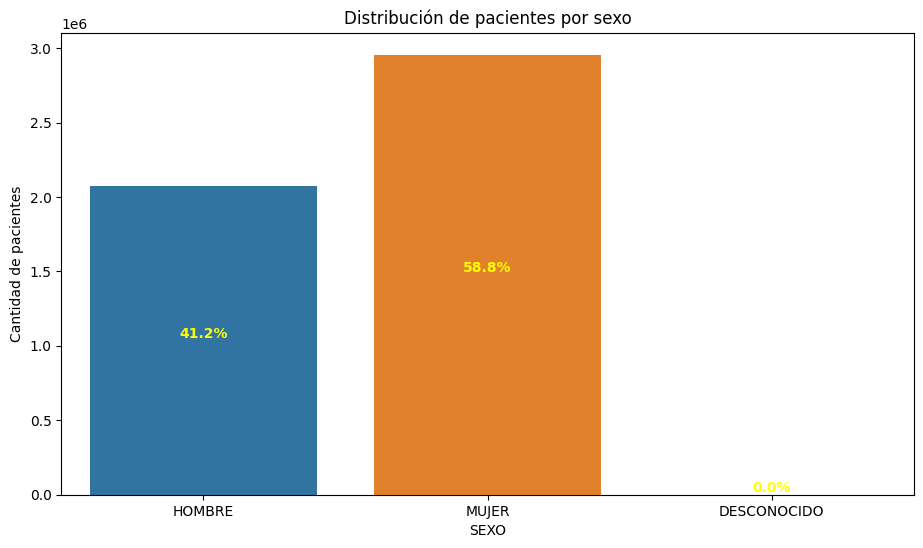

In [42]:
plt.figure(figsize=(11, 6))
ax = sns.countplot(data=df_consolidado, x='SEXO')
plt.title('Distribución de pacientes por sexo')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)

# Añadir porcentaje en las barras
total = len(df_consolidado)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() /2
    ax.annotate(percentage, (x, y), ha='center', va='bottom', color='yellow', weight='bold')

plt.show()

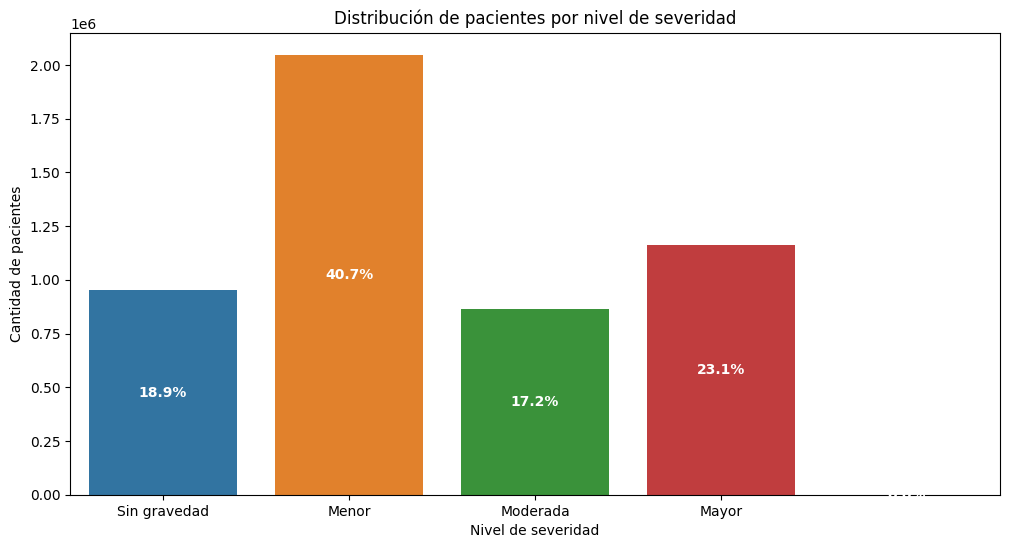

In [43]:
# Distribución por nivel de severidad
#primero se formatea la severidad

def clean_severity(value):
    """
    Convierte cualquier valor a string, asegurando consistencia 
    y manejando posibles valores nulos o desconocidos.
    """
    # Si el valor ya es nulo (None o NaN), lo estandarizamos
    if pd.isna(value):
        return 'DESCONOCIDO'
    
    try:
        # Convertimos a int primero para quitar decimales (ej: 2.0 -> 2)
        # y luego a string para estandarizar
        return str(int(float(value)))
    except (ValueError, TypeError):
        # Si no es convertible a número (como 'DESCONOCIDO'), 
        # lo devolvemos como string en mayúsculas
        return str(value).strip().upper()

# Aplicación en el DataFrame
df_consolidado['IR_29301_SEVERIDAD'] = df_consolidado['IR_29301_SEVERIDAD'].apply(clean_severity)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_consolidado, x='IR_29301_SEVERIDAD')
plt.title('Distribución de pacientes por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Cantidad de pacientes')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Sin gravedad', 'Menor', 'Moderada', 'Mayor'])

# Añadir porcentaje en las barras
total = len(df_consolidado)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', color='white', weight='bold')

plt.show()

In [44]:
def optimize_dates(df, column_name):
    # Intentamos primero el formato Día-Mes-Año (típico en Latam)
    # 'coerce' pone NaT en lo que no coincida, permitiéndonos identificar fallos
    dmy = pd.to_datetime(df[column_name], format='%d-%m-%Y', errors='coerce')
    
    # Intentamos el formato ISO Año-Mes-Día para los que fallaron
    ymd = pd.to_datetime(df[column_name], format='%Y-%m-%d', errors='coerce')
    
    # Combinamos: donde dmy es nulo, usamos ymd
    df[column_name] = dmy.fillna(ymd)
    
    return df

In [45]:
# 1. Intentamos la conversión masiva para ambos formatos
dmy = pd.to_datetime(df_consolidado['FECHA_NACIMIENTO'], format='%d-%m-%Y', errors='coerce')
ymd = pd.to_datetime(df_consolidado['FECHA_NACIMIENTO'], format='%Y-%m-%d', errors='coerce')

# 2. Creamos la columna de tipo (por defecto 'Invalid')
df_consolidado['TIPO_FECHA_NACIMIENTO'] = 'Invalid'

# 3. Asignamos etiquetas y valores basados en qué máscara tuvo éxito
# Usamos .loc para modificar en bloque (muy rápido)
df_consolidado.loc[ymd.notna(), 'TIPO_FECHA_NACIMIENTO'] = 'YMD'
df_consolidado.loc[dmy.notna(), 'TIPO_FECHA_NACIMIENTO'] = 'DMY'

# 4. Consolidamos la fecha final (priorizando DMY si hubiera ambigüedad)
df_consolidado['FECHA_NACIMIENTO'] = dmy.fillna(ymd)
print(df_consolidado['TIPO_FECHA_NACIMIENTO'].value_counts())

TIPO_FECHA_NACIMIENTO
YMD        5026588
Invalid         36
Name: count, dtype: int64


In [46]:
# 1. Intentamos las conversiones de forma masiva (vectorizada)
# Esto es órdenes de magnitud más rápido que un .apply()
dmy = pd.to_datetime(df_consolidado['FECHA_INGRESO'], format='%d-%m-%Y', errors='coerce')
ymd = pd.to_datetime(df_consolidado['FECHA_INGRESO'], format='%Y-%m-%d', errors='coerce')

# 2. Creamos la columna de tipo usando np.select (una estructura IF-ELIF-ELSE vectorizada)
condiciones = [
    dmy.notna(),
    ymd.notna()
]
opciones = ['DMY', 'YMD']

df_consolidado['TIPO_FECHA_INGRESO'] = np.select(condiciones, opciones, default='Invalid')

# 3. Consolidamos la fecha final: priorizamos el éxito de DMY, luego YMD
df_consolidado['FECHA_INGRESO'] = dmy.fillna(ymd)

In [23]:


# Convertimos a strings para asegurar consistencia antes de la lógica
series_fechas = df_consolidado['FECHA_INGRESO'].astype(str)

# 1. Intentamos las dos conversiones de forma masiva (vectorizada)
dmy = pd.to_datetime(series_fechas, format='%d-%m-%Y', errors='coerce')
ymd = pd.to_datetime(series_fechas, format='%Y-%m-%d', errors='coerce')

# 2. Definimos la columna de tipo con lógica vectorizada (np.select)
condiciones = [dmy.notna(), ymd.notna()]
opciones = ['DMY', 'YMD']
df_consolidado['TIPO_FECHA_INGRESO'] = np.select(condiciones, opciones, default='Invalid')

# 3. Guardamos la fecha final consolidada
df_consolidado['FECHA_INGRESO'] = dmy.fillna(ymd)


In [47]:

# Convertimos FECHAALTA a datetime
dmy_alta = pd.to_datetime(df_consolidado['FECHAALTA'], format='%d-%m-%Y', errors='coerce')
ymd_alta = pd.to_datetime(df_consolidado['FECHAALTA'], format='%Y-%m-%d', errors='coerce')
df_consolidado['FECHAALTA'] = dmy_alta.fillna(ymd_alta)

# Calculamos la edad del paciente y la duración de la estancia
df_consolidado['EDAD'] = ((df_consolidado['FECHA_INGRESO'] - df_consolidado['FECHA_NACIMIENTO']).dt.days / 365.25).round().astype('Int64')
df_consolidado['DIAS_ESTANCIA'] = (df_consolidado['FECHAALTA'] - df_consolidado['FECHA_INGRESO']).dt.days

# Convertimos los códigos de severidad a tipo numérico
df_consolidado['IR_29301_SEVERIDAD'] = pd.to_numeric(df_consolidado['IR_29301_SEVERIDAD'], errors='coerce')

# Convertimos el peso GRD a tipo float
#df_grd['IR_29301_PESO'] = df_grd['IR_29301_PESO'].str.replace(',', '.').str.strip()
df_consolidado['IR_29301_PESO'] = pd.to_numeric(df_consolidado['IR_29301_PESO'], errors='coerce')

# Verificamos las nuevas columnas
df_consolidado[['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA', 'EDAD', 'DIAS_ESTANCIA']].head()

print("--- df.head() ---")
display(df_consolidado.head())          # primeras 5 filas

print("\n--- df.shape ---")
print(df_consolidado.shape)             # (200, 6) -> 200 filas, 6 columnas

print("\n--- df.info() ---")
df_consolidado.info()                   # tipos + nulos

print("\n--- df.describe() ---")
display(df_consolidado.describe())                    # estadísticas numéricas

print("\n--- df.describe(include='all') ---")
display(df_consolidado.describe(include="all"))       # incluye categóricas

--- df.head() ---


,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,EDAD,DIAS_ESTANCIA
0,115100,HOMBRE,2022-01-02,COLCHAGUA,SAN FERNANDO,LIBERTADOR B. O HIGGINS,2022-08-01,2022-08-09,DOMICILIO,Q03.9,011113,NaN,3.0,YMD,YMD,1,8.0
1,112103,MUJER,1981-07-05,COPIAPO,COPIAPO,ATACAMA,2022-11-01,2022-11-04,DOMICILIO,I47.1,051401,NaN,1.0,YMD,YMD,41,3.0
2,110150,MUJER,1941-06-30,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-30,2022-07-06,FALLECIDO,S72.00,084103,NaN,3.0,YMD,YMD,81,6.0
3,110150,MUJER,1997-01-26,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-07-04,2022-07-07,DOMICILIO,O80.0,146131,NaN,1.0,YMD,YMD,25,3.0
4,110150,MUJER,1950-06-03,MELIPILLA,MELIPILLA,METROPOLITANO OCCIDENTE,2022-06-01,2022-07-04,DOMICILIO,J40,044213,NaN,3.0,YMD,YMD,72,33.0



--- df.shape ---
(5026624, 17)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5026624 entries, 0 to 5026623
Data columns (total 17 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   COD_HOSPITAL           int64         
 1   SEXO                   object        
 2   FECHA_NACIMIENTO       datetime64[ns]
 3   PROVINCIA              object        
 4   COMUNA                 object        
 5   SERVICIO_SALUD         object        
 6   FECHA_INGRESO          datetime64[ns]
 7   FECHAALTA              datetime64[ns]
 8   TIPOALTA               object        
 9   DIAGNOSTICO1           object        
 10  IR_29301_COD_GRD       object        
 11  IR_29301_PESO          float64       
 12  IR_29301_SEVERIDAD     float64       
 13  TIPO_FECHA_NACIMIENTO  object        
 14  TIPO_FECHA_INGRESO     object        
 15  EDAD                   Int64         
 16  DIAS_ESTANCIA          float64       
dtypes: Int64(1), d

,COD_HOSPITAL,FECHA_NACIMIENTO,FECHA_INGRESO,FECHAALTA,IR_29301_PESO,IR_29301_SEVERIDAD,EDAD,DIAS_ESTANCIA
count,5.026624e+06,5026588,5026553,5026606,821339.000000,5.026534e+06,5026533.0,5.026553e+06
mean,1.138219e+05,1977-07-16 14:57:05.939663296,2022-04-12 02:47:20.720628480,2022-04-18 00:28:59.668952576,1.099390,1.437245e+00,44.736312,5.895872e+00
min,1.011000e+05,1894-08-10 00:00:00,2012-09-16 00:00:00,2019-01-01 00:00:00,0.000000,0.000000e+00,0.0,-5.000000e+00
25%,1.091000e+05,1955-10-08 00:00:00,2021-02-11 00:00:00,2021-02-18 00:00:00,0.487200,1.000000e+00,25.0,1.000000e+00
50%,1.131800e+05,1977-08-05 00:00:00,2022-08-04 00:00:00,2022-08-10 00:00:00,0.712400,1.000000e+00,45.0,3.000000e+00
75%,1.181000e+05,1996-11-19 00:00:00,2023-10-26 00:00:00,2023-11-02 00:00:00,1.179900,2.000000e+00,67.0,6.000000e+00
max,2.007170e+05,2024-12-31 00:00:00,2024-12-31 00:00:00,2024-12-31 00:00:00,20.646100,3.000000e+00,125.0,3.146000e+03
std,7.803639e+03,NaN,NaN,NaN,1.404264,9.844133e-01,25.560151,1.335572e+01



--- df.describe(include='all') ---


,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA,SERVICIO_SALUD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,EDAD,DIAS_ESTANCIA
count,5.026624e+06,5026624,5026588,5026624,5026624,5026624,5026553,5026606,5026624,5026545,5026624,821339.000000,5.026534e+06,5026624,5026624,5026533.0,5.026553e+06
unique,NaN,3,NaN,58,347,32,NaN,NaN,12,9548,2055,NaN,NaN,2,3,<NA>,NaN
top,NaN,MUJER,NaN,SANTIAGO,PUENTE ALTO,METROPOLITANO SURORIENTE,NaN,NaN,DOMICILIO,H26.9,022360,NaN,NaN,YMD,YMD,<NA>,NaN
freq,NaN,2955312,NaN,1225037,198032,453382,NaN,NaN,4510650,139768,183744,NaN,NaN,5026588,3986966,<NA>,NaN
mean,1.138219e+05,NaN,1977-07-16 14:57:05.939663296,NaN,NaN,NaN,2022-04-12 02:47:20.720628480,2022-04-18 00:28:59.668952576,NaN,NaN,NaN,1.099390,1.437245e+00,NaN,NaN,44.736312,5.895872e+00
min,1.011000e+05,NaN,1894-08-10 00:00:00,NaN,NaN,NaN,2012-09-16 00:00:00,2019-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,NaN,0.0,-5.000000e+00
25%,1.091000e+05,NaN,1955-10-08 00:00:00,NaN,NaN,NaN,2021-02-11 00:00:00,2021-02-18 00:00:00,NaN,NaN,NaN,0.487200,1.000000e+00,NaN,NaN,25.0,1.000000e+00
50%,1.131800e+05,NaN,1977-08-05 00:00:00,NaN,NaN,NaN,2022-08-04 00:00:00,2022-08-10 00:00:00,NaN,NaN,NaN,0.712400,1.000000e+00,NaN,NaN,45.0,3.000000e+00
75%,1.181000e+05,NaN,1996-11-19 00:00:00,NaN,NaN,NaN,2023-10-26 00:00:00,2023-11-02 00:00:00,NaN,NaN,NaN,1.179900,2.000000e+00,NaN,NaN,67.0,6.000000e+00
max,2.007170e+05,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,2024-12-31 00:00:00,2024-12-31 00:00:00,NaN,NaN,NaN,20.646100,3.000000e+00,NaN,NaN,125.0,3.146000e+03


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


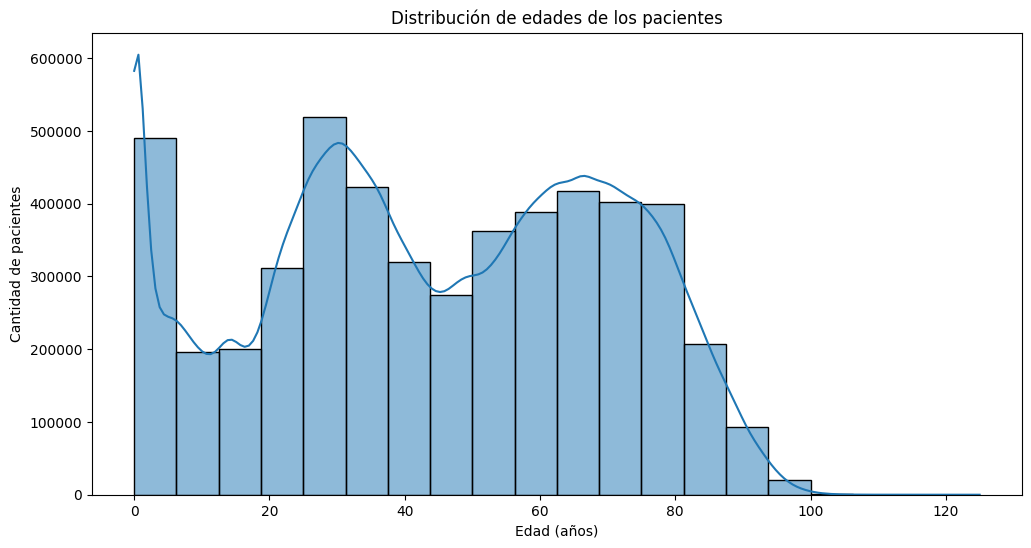

In [30]:
plt.figure(figsize=(12, 6))
# Filter data and convert EDAD to float to ensure compatibility with KDE
edad_data = df_consolidado.dropna(subset=['EDAD'])['EDAD'].astype(float)
sns.histplot(edad_data, bins=20, kde=True)
plt.title('Distribución de edades de los pacientes')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

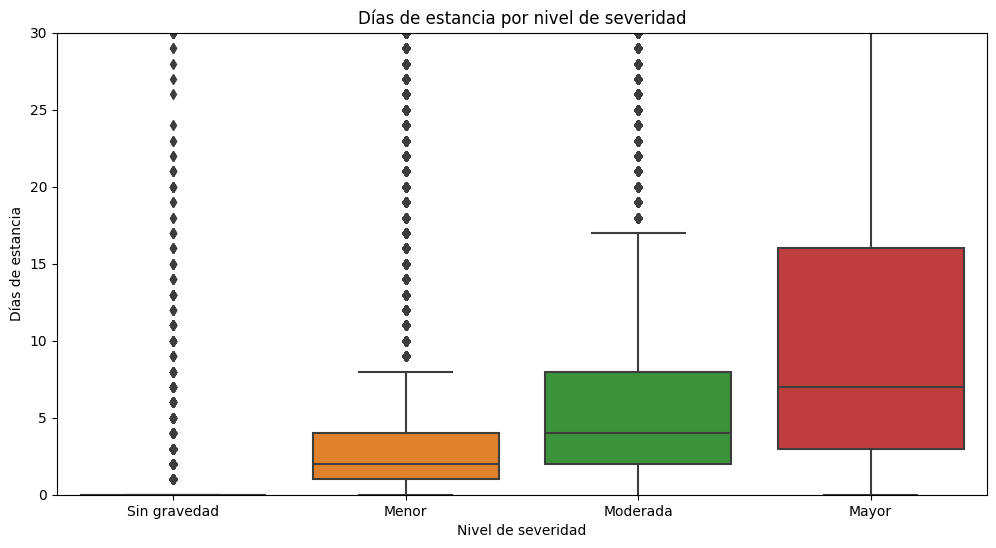

In [32]:
# Relación entre severidad y días de estancia
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_consolidado, x='IR_29301_SEVERIDAD', y='DIAS_ESTANCIA')
plt.title('Días de estancia por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Días de estancia')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Sin gravedad', 'Menor', 'Moderada', 'Mayor'])
plt.ylim(0, 30)  # Limitamos el eje Y para mejor visualización
plt.show()

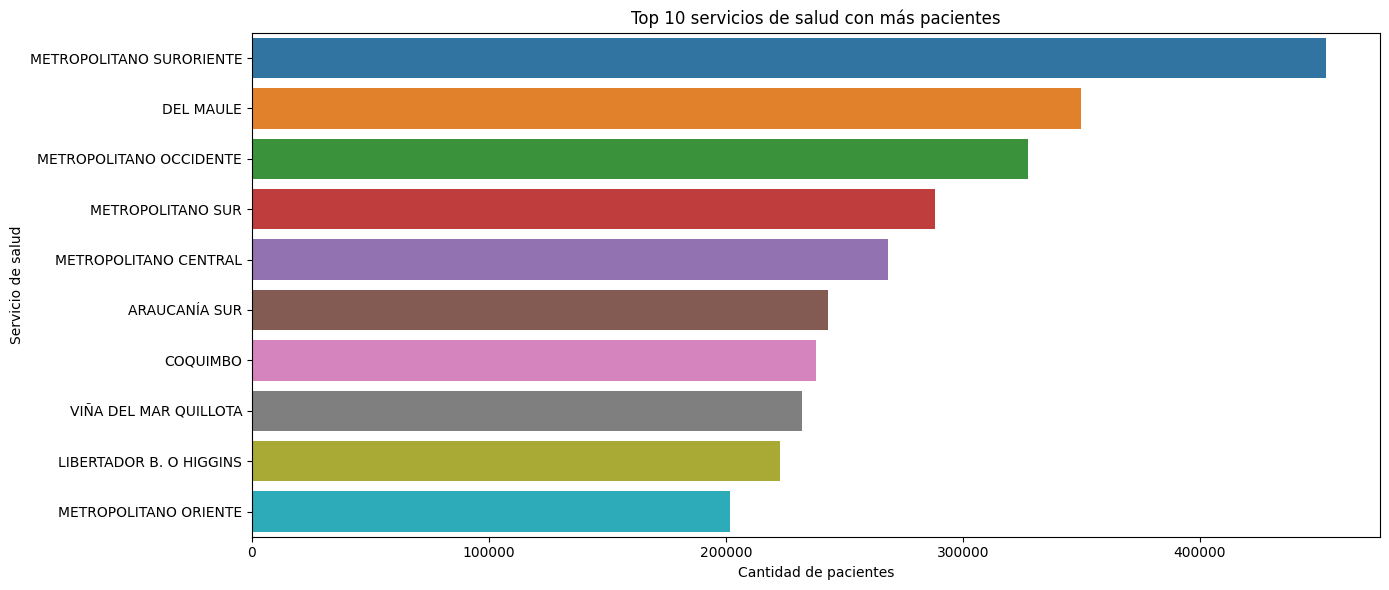

In [38]:
# Top 10 servicios de salud con más pacientes
plt.figure(figsize=(14, 6))
top_10_servicios = df_consolidado['SERVICIO_SALUD'].value_counts().head(10)
sns.barplot(y=top_10_servicios.index, x=top_10_servicios.values, orient='h')
plt.title('Top 10 servicios de salud con más pacientes')
plt.ylabel('Servicio de salud')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()


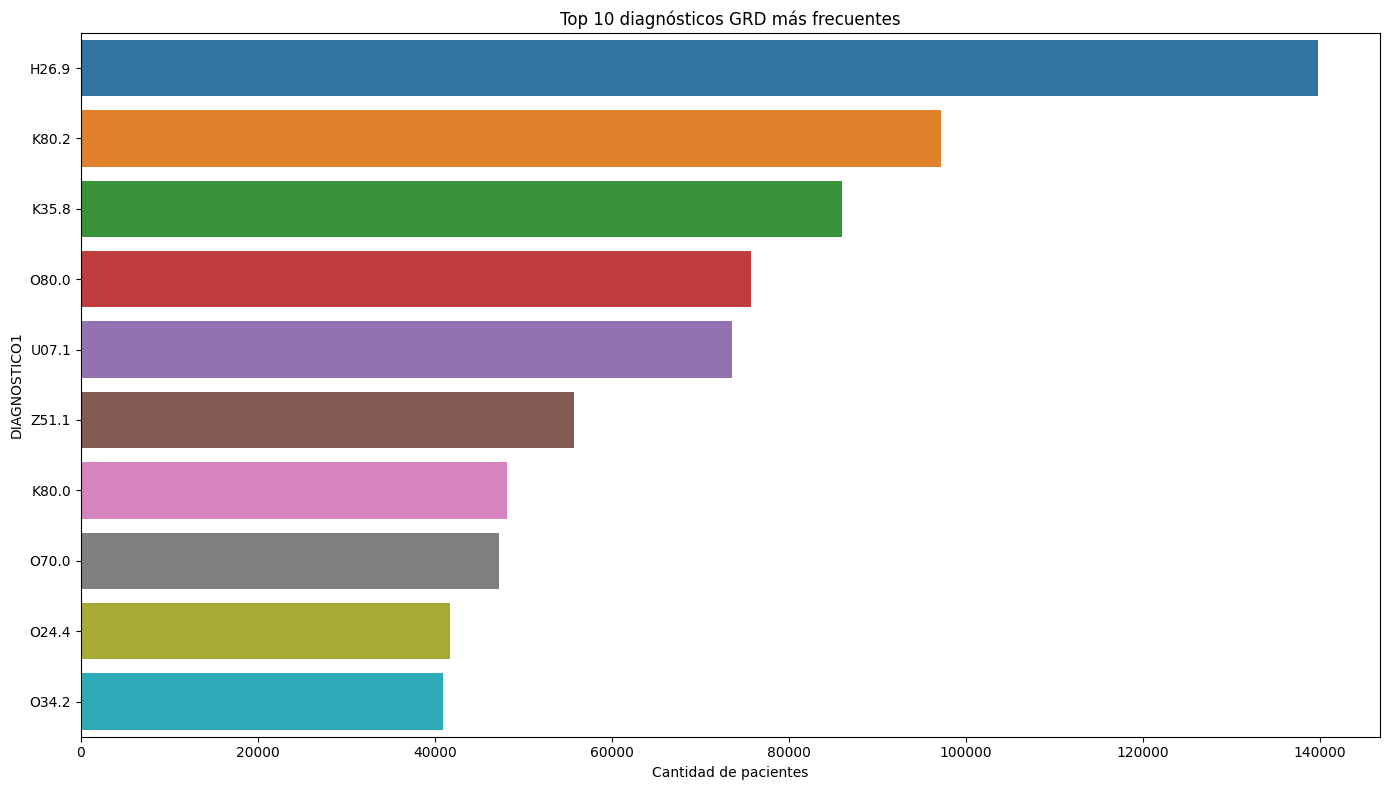

In [40]:
# Top 10 diagnósticos más frecuentes
plt.figure(figsize=(14, 8))
top_10_grd = df_consolidado['DIAGNOSTICO1'].value_counts().head(10)
sns.barplot(x=top_10_grd.values, y=top_10_grd.index)
plt.title('Top 10 diagnósticos GRD más frecuentes')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

<Figure size 3000x1000 with 0 Axes>

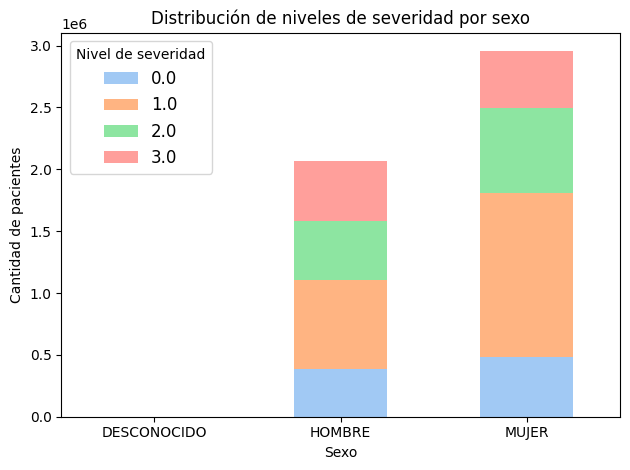

In [49]:
plt.figure(figsize=(30, 10))
crosstab = pd.crosstab(df_consolidado['SEXO'], df_consolidado['IR_29301_SEVERIDAD'])
crosstab.plot(kind='bar', stacked=True, color=sns.color_palette("pastel"))
plt.title('Distribución de niveles de severidad por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pacientes')
plt.legend(title='Nivel de severidad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


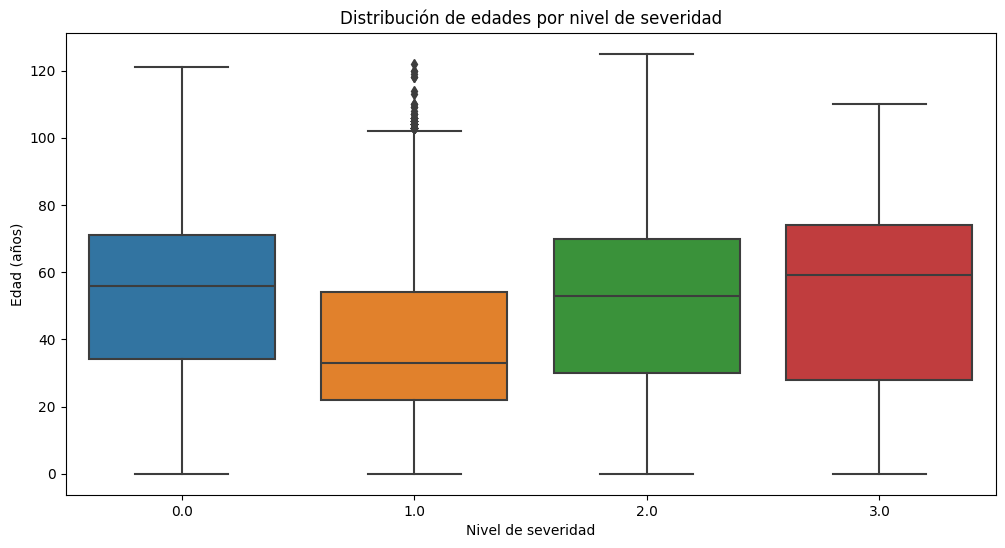

In [53]:
# Relación entre edad y severidad
plot_data = df_consolidado.dropna(subset=['IR_29301_SEVERIDAD', 'EDAD']).copy()
plot_data['IR_29301_SEVERIDAD'] = plot_data['IR_29301_SEVERIDAD'].astype('category')
plot_data['EDAD'] = plot_data['EDAD'].astype(float)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='IR_29301_SEVERIDAD', y='EDAD')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.show()

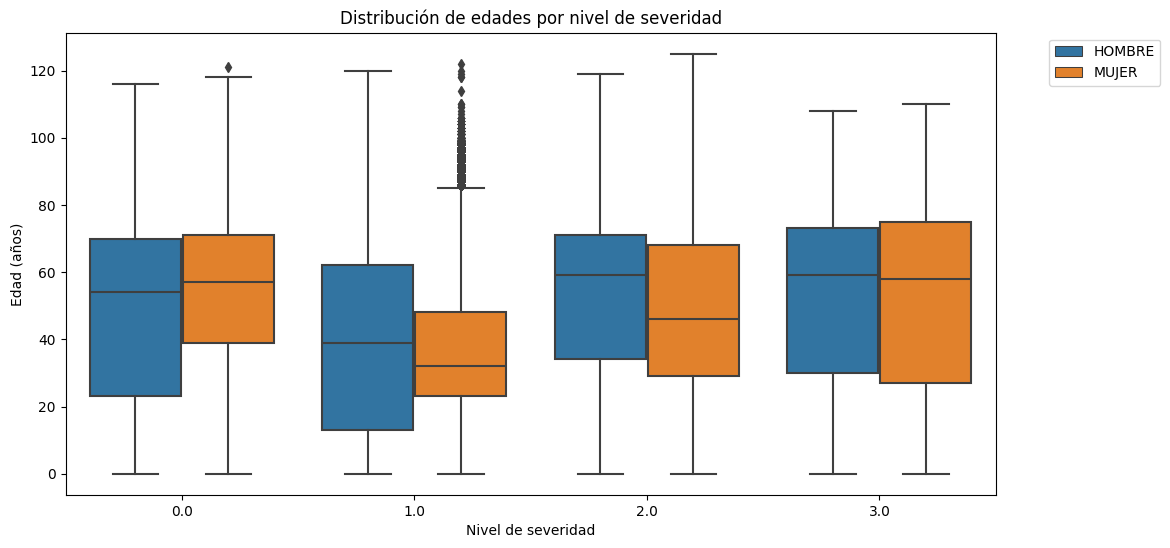

In [58]:
plt.figure(figsize=(12, 6))
data = df_consolidado[df_consolidado['SEXO'].notna() & (df_consolidado['SEXO'] != 'DESCONOCIDO')].dropna(subset=['EDAD', 'IR_29301_SEVERIDAD'])
sns.boxplot(data=data, x='IR_29301_SEVERIDAD', y='EDAD', hue='SEXO')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Mueve la leyenda fuera del área del gráfico
plt.show()

In [62]:
# Top 5 hospitales con mayor promedio de peso GRD (mayor complejidad)
df_hospitales = pd.read_csv("datos/Hospitales.csv", header=None, names=['COD_HOSPITAL', 'NOMBRE_HOSPITAL'], sep="|")
hospital_peso = df_consolidado.groupby('NOMBRE_HOSPITAL')['IR_29301_PESO'].agg(['mean', 'median', 'count'])
hospital_peso = hospital_peso[hospital_peso['count'] > 100]  # Filtramos hospitales con pocos casos
hospital_peso = hospital_peso.sort_values('mean', ascending=False).head(5)

# Calculamos la media y mediana de todos los hospitales
mean_all = df_consolidado['IR_29301_PESO'].mean()
median_all = df_consolidado['IR_29301_PESO'].median()

plt.figure(figsize=(14, 10))
ax = sns.barplot(y=hospital_peso.index, x=hospital_peso['mean'], orient='h', label='Media')
plt.title('Top 5 hospitales con mayor promedio de peso GRD')
plt.ylabel('Hospital')
plt.xlabel('Peso GRD promedio')
plt.xticks(rotation=0, ha='right')

# Añadimos líneas verticales para la media y mediana de todos los hospitales
plt.axvline(mean_all, color='r', linestyle='--', label=f'Media de todos los hospitales: {mean_all:.2f}')
plt.axvline(median_all, color='g', linestyle='-', label=f'Mediana de todos los hospitales: {median_all:.2f}')

# Añadimos el promedio dentro de la barra en color blanco
for p in ax.patches:
    width = p.get_width()
    plt.text(width - 0.1, p.get_y() + p.get_height() / 2, f'{width:.2f}', ha='center', va='center', color='white', weight='bold')

plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'datos/Hospitales.csv'